In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW
from torch.utils.data import Dataset, DataLoader
import pickle as pkl
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import json

# quick hack for now
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#TODO: test normalising per client rather than globally
#TODO: if no improvement, test using nrmse loss function in training

In [181]:
# constants
SEQ_LENGTH = 24*7
BATCH_SIZE = 32
RANDOM_SEED = 42

# taking random stride across sequences in training, to reduce compute while ensuring sufficient sampling across all times
# note that fixed with random seed
TRAIN_STRIDE_LOW = 12
TRAIN_STRIDE_HIGH = 23
# for validation, use fixed stride for reproducibility
VALIDATE_STRIDE = 12
# for test using stride of 1 so can get full forecast across all time points, to simulate production
TEST_STRIDE = 1

# embedding dim size
EMBEDDING_DIM = 8
# hidden size in LSTM
HIDDEN_SIZE = 10

# base learning rate in optimer
LEARNING_RATE = 1e-5
# weight decay in optimiser
WEIGHT_DECAY = 1e-3

# epochs to run through data
EPOCHS = 12
# patience and delta for early stopping
PATIENCE = 5
DELTA = 1e-3

In [147]:
# loading in the training, validation and testing data
with open('../data/processed/df_seq_train.pkl', 'rb') as f:
    df_train = pkl.load(f)

with open('../data/processed/df_seq_validate.pkl', 'rb') as f:
    df_validate = pkl.load(f)

with open('../data/processed/df_seq_test.pkl', 'rb') as f:
    df_test = pkl.load(f)

In [148]:
# try per client standardisation

# get mean and std per client across al features
df_mean_std_usage = df_train.groupby(level='client_id')['hourly_usage_kwh'].agg(['mean', 'std'])

# convert to a dictionary for accessing later. Use index as key
dict_mean_std_usage = df_mean_std_usage.to_dict(orient='index')

In [149]:
def standardise_per_client(group):
    """ Takes in a pandas groupby object, containing hourly usage data, and standardises using client-specifc mean and standard deviation 
     in usage. Note assumes that table containing mean and standard eeviation are not multiindex object """
    
    # get client id of a group (assumed the same within group)
    client_id = int(np.unique(group.index.get_level_values('client_id'))[0])
    # for each column in the group, update values using corresponding mean and std
    return (group - dict_mean_std_usage[client_id]['mean'])/dict_mean_std_usage[client_id]['std']

In [151]:
df_train_scaled = df_train.copy()
df_validate_scaled = df_validate.copy()
df_test_scaled = df_test.copy()

# standardise per client (note that cyclical time features already between -1 and 1 so not standardising these)
df_train_scaled['hourly_usage_kwh'] = df_train.groupby(level='client_id')['hourly_usage_kwh'].transform(lambda g: standardise_per_client(g))
df_validate_scaled['hourly_usage_kwh'] = df_validate.groupby(level='client_id')['hourly_usage_kwh'].transform(lambda g: standardise_per_client(g))
df_test_scaled['hourly_usage_kwh'] = df_test.groupby(level='client_id')['hourly_usage_kwh'].transform(lambda g: standardise_per_client(g))

In [152]:
# get mean and standard deviations of mean usage across clients
mean_of_mean_usages = df_mean_std_usage['mean'].mean()
std_of_mean_usages = df_mean_std_usage['mean'].std()

# use to standardise mean usages (using training data only!)
scaled_mean_client_usage = (df_mean_std_usage['mean'] - mean_of_mean_usages)/std_of_mean_usages

# use pd.merge the series and dataframe, on the client id multiindex
df_train_scaled = pd.merge(left=df_train_scaled, right=scaled_mean_client_usage, how='left', on='client_id')
df_validate_scaled = pd.merge(left=df_validate_scaled, right=scaled_mean_client_usage, how='left', on='client_id')
df_test_scaled = pd.merge(left=df_test_scaled, right=scaled_mean_client_usage, how='left', on='client_id')

In [153]:
# now convert to tensor format ready for model
data_train_preprocesed = torch.tensor(df_train_scaled.to_numpy(), dtype=torch.float32)
data_validate_preprocesed = torch.tensor(df_validate_scaled.to_numpy(), dtype=torch.float32)
data_test_preprocesed = torch.tensor(df_test_scaled.to_numpy(), dtype=torch.float32)

In [154]:
# get client ids (for readability)
client_ids_train = df_train.index.get_level_values('client_id')
client_ids_validate = df_validate.index.get_level_values('client_id')
client_ids_test = df_test.index.get_level_values('client_id')

# unique client ids in data (ensured during feature engineering that same across all data)
client_ids_unique = client_ids_validate.unique()

In [155]:
# create dictionaries of data where key represents client and value all data for that client
# (that will access during training)
data_train_dict = {client_id: data_train_preprocesed[client_ids_train == client_id] for client_id in client_ids_unique}
data_validate_dict = {client_id: data_validate_preprocesed[client_ids_validate == client_id] for client_id in client_ids_unique}
data_test_dict = {client_id: data_test_preprocesed[client_ids_test == client_id] for client_id in client_ids_unique}

In [156]:
# total valid number starting indexes (and thus valid number of sequences)
tot_num_start_indx_train = [data.shape[0] - SEQ_LENGTH for client_id, data in data_train_dict.items()]
tot_num_start_indx_validate = [data.shape[0] - SEQ_LENGTH for client_id, data in data_validate_dict.items()]
tot_num_start_indx_test = [data.shape[0] - SEQ_LENGTH for client_id, data in data_test_dict.items()]

In [157]:
# random number generator for stide in training sequences
rng = np.random.default_rng(seed=RANDOM_SEED)

# random goes isnide loop here so that random stride at every iteration
index_map_train = [(client_id, start_index) for i, client_id in enumerate(client_ids_unique) for start_index in range(0, tot_num_start_indx_train[i], rng.integers(low=TRAIN_STRIDE_LOW, high=TRAIN_STRIDE_HIGH, size=1)[0])]
index_map_validate = [(client_id, start_index) for i, client_id in enumerate(client_ids_unique) for start_index in range(0, tot_num_start_indx_validate[i], VALIDATE_STRIDE)]
index_map_test = [(client_id, start_index) for i, client_id in enumerate(client_ids_unique) for start_index in range(0, tot_num_start_indx_test[i], TEST_STRIDE)]

In [158]:
# create Dataset class to retrieve the sequences, given an index

class SeqExtractionDataSet(Dataset):

    def __init__(self, data_dict, idx_map, SEQ_LENGTH=24*7):
        
        # set idx map, which use to get total number of samples
        # set data dict which extract the samples from
        # set the sequence length which gives the length of each sample X_seq
        self.data_dict = data_dict
        self.idx_map = idx_map
        self.SEQ_LENGTH = SEQ_LENGTH


    def __getitem__(self, idx):
        """ take integer idx from the dataloader and return the features at all time points in 
        context window SEQ_LENGTH (X_seq), along with the target (y_seq) and corresponding client_id EMBEDDING
         INDEX (not the id itself).
         
        if mode set to 'train' then extracts from training set. 'validate' extracts from validation set. 'test' extracts 
        from the test set. Else gives an error.

        Note use of intermediate index map to extract sequences on a per client basis """

        # idx is a numeric integer returned by the dataloader (which it creates using length of all samples)
        # so use this integer to extract a corresponding index from index map, for a sequence
        # then extract the client_id and starting index of sequence from the corresopnding tuple
        client_id = self.idx_map[idx][0]
        seq_start_idx = self.idx_map[idx][1]

        # and to extract the corresponding context window and target
        X_seq = self.data_dict[client_id][seq_start_idx: seq_start_idx + self.SEQ_LENGTH, :]
        # for target, just want usage only
        y_seq = self.data_dict[client_id][seq_start_idx + self.SEQ_LENGTH, 0]

        # returning id, just so can use if want to evaluate performance on clients
        return X_seq, y_seq, client_id


    def __len__(self):
        """ returns the total number of samples in the Dataset. Used by dataloader """

        #TODO: need more tests for shapes compatibility etc.
        return len(self.idx_map)

In [159]:
# now create instance of the dataset for train, test, and validate
dataset_train = SeqExtractionDataSet(data_dict=data_train_dict, idx_map=index_map_train, SEQ_LENGTH=SEQ_LENGTH)
dataset_validate = SeqExtractionDataSet(data_dict=data_validate_dict, idx_map=index_map_validate, SEQ_LENGTH=SEQ_LENGTH)
dataset_test = SeqExtractionDataSet(data_dict=data_test_dict, idx_map=index_map_test, SEQ_LENGTH=SEQ_LENGTH)

# and corresponding dataloaders. Fine to shuffle because using sequences here rather than time points
dataloader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
dataloader_validate = DataLoader(dataset_validate, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
# don't bother shuffling test as not computing the loss here (and don't drop last batch as will concat)
dataloader_test = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [169]:
# number of features
n_features = len(df_train_scaled.columns)

In [182]:
# now implement the LSTM class

# for now keep vanilla with no multiple layers
class LSTMDemand(nn.Module):

    def __init__(self, n_features, hidden_size=HIDDEN_SIZE):

        super().__init__()

        # LSTM layer
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, batch_first=True)

        # final fully connected layer, taking hidden states and producing output value for next point in time
        self.fc = nn.Linear(in_features=hidden_size, out_features=1)
    

    def forward(self, input_seq_batch):

        # just vanilla LSTM with features
        lstm_output, _ = self.lstm(input_seq_batch)

        # and final feedforwards layer. Note need to extract the output from the final timestep in sequence (because)
        # output form LSTM returns hidden state of final LSTM layer at all sequence timesteps
        return self.fc(lstm_output[:, -1, :]).squeeze(-1)


model = LSTMDemand(n_features=n_features, hidden_size=HIDDEN_SIZE)

In [183]:
# set up the optimiser
# implementing weight decay (to ensure inputs into LSTM do not become too large - helsp avoid vanishing gradient issue
# at the input, forget and output gates)

#  AdamW with more consistent regularisation accross weights
optimiser = AdamW(params=model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# use MSE for criterion for training
criterion = nn.MSELoss()

In [184]:
# create a class for early stopping and tracking of losses

class ConvergenceTracker():

    def __init__(self, patience, delta):
        
        # tracking training and validation losses during the run
        self.training_losses = []
        self.validation_losses = []

        self.patience = patience
        self.delta = delta

        # track the model and epoch where the loss was last decreasing
        self.prev_dec_model = None
        self.prev_dec_epoch = None
        # track the previous loss, at every iteration of this class
        self.prev_loss = None
        # counts num iterations since loss last decreased
        self.no_improve_count = 0
        # flag to stop training if patience exceeded
        self.stop_training = False
    
    def check_early_stop(self, val_loss, model_state_dict, epoch):
        
        # need to save version with best weights and biases, while using previous loss
        # as metric to increment counter
        # test using previous loss where loss decreased, rather than the minimum loss
        if self.prev_loss is None or val_loss < self.prev_loss - self.delta:

            # if model is improving, reset the counter
            # and the counter
            self.no_improve_count = 0

            # update saved model (as this is the weights and biases from last model where loss had decreased) 
            self.prev_dec_model = model_state_dict
            self.prev_dec_epoch = epoch

            # then set the previous loss to this one
            self.prev_loss = val_loss
        else:
            # otherwise increment the counter
            self.no_improve_count += 1

            # set the previous loss to this one
            self.prev_loss = val_loss

            # if exceeds patience, signal to end the run
            if self.no_improve_count >= self.patience:
                self.stop_training = True
    
    def plot_losses(self, save_figure=False, show_figure=True, save_path=''):
        
        plt.figure()
        plt.plot(self.validation_losses, label='validation')
        plt.plot(self.training_losses, label='train')
        plt.legend()
        
        if save_figure:
            plt.savefig(save_path)
        if show_figure:
            plt.show()
        
        plt.close()

In [185]:
# create instnace of early stopping class
convergence_tracker = ConvergenceTracker(patience=PATIENCE, delta=DELTA)

In [188]:
# and now the main training loop

# first loop over epochs
for epoch in range(EPOCHS):

    print(f'\n starting epoch {epoch}')
    losses_train = []
    model.train()
    
    for batch_idx, (X_seqs, labels, client_ids) in enumerate(dataloader_train):

        # do forwards pass
        predictions = model(X_seqs)

        # compute loss
        loss = criterion(predictions, labels)
        loss.backward()

        # step forwards
        optimiser.step()
        optimiser.zero_grad()
    
        # append batch training loss to list
        with torch.no_grad():
            losses_train.append(loss.item())

    print(f'training at epoch {epoch} completed')
    
    with torch.no_grad():
        # after training completed, append batch-averaged training loss to list
        convergence_tracker.training_losses.append(np.mean(losses_train))

    # at every other epoch
    if epoch % 2 == 0:  #epoch > 10 and 
        
        # list of losses which will average over (reset at each validation loop)
        losses_val = []
        # at end of epoch, now evaluate the validation loss
        model.eval()
        with torch.no_grad():
            for batch_idx, (X_seqs_val, labels_val, _) in enumerate(dataloader_validate):

                preds_val = model(X_seqs_val)
                losses_val.append(criterion(preds_val, labels_val).item())
            
            # after going through batches average loss across them
            losses_val_average = np.mean(losses_val)

            # and evaluate early stopping
            convergence_tracker.check_early_stop(val_loss=losses_val_average, epoch=epoch, model_state_dict=model.state_dict())

            # if time to stop then do so and restore best performing weights and biases
            if convergence_tracker.stop_training is True:
                # print(f'early stopping criterion reached at {epoch} epochs. restoring to weights and biases at {early_stop_checker.best_model_epoch} epochs')
                print(f'early stopping criterion reached at {epoch} epochs. restoring to weights and biases at {convergence_tracker.prev_dec_epoch} epochs')

                # model.load_state_dict(early_stop_checker.best_model)
                model.load_state_dict(convergence_tracker.prev_dec_model)

                # and save the mode state dictionary
                with open('../models/LSTM.pkl', 'wb') as f:
                    pkl.dump(convergence_tracker.prev_dec_model, f)
                
                # then end training
                break
                
            # append average loss to its own list for plotting later
            convergence_tracker.validation_losses.append(losses_val_average)

    if epoch % 5 == 0:
        convergence_tracker.plot_losses(show_figure=False, save_figure=True, save_path='../plots/losses_in_prog')


 starting epoch 0
training at epoch 0 completed

 starting epoch 1
training at epoch 1 completed

 starting epoch 2
training at epoch 2 completed

 starting epoch 3
training at epoch 3 completed

 starting epoch 4
training at epoch 4 completed

 starting epoch 5
training at epoch 5 completed

 starting epoch 6
training at epoch 6 completed

 starting epoch 7
training at epoch 7 completed

 starting epoch 8
training at epoch 8 completed

 starting epoch 9


KeyboardInterrupt: 

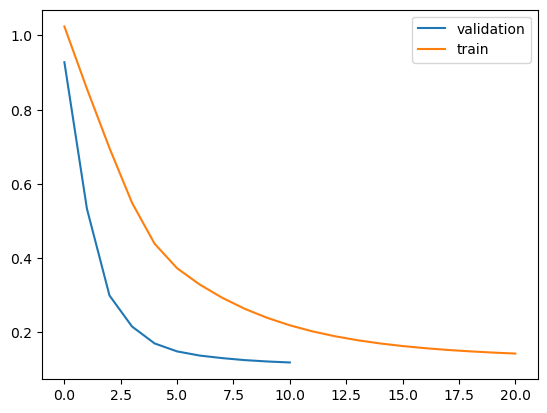

In [189]:
# plot the loss (validation loss computed once every 2 epcohs currently)

convergence_tracker.plot_losses()
# plt.plot(convergence_tracker.validation_losses, label='validation')
# plt.plot(convergence_tracker.training_losses, label='train')
# plt.legend()
# plt.savefig('../plots/train_val_loss_after_200_epochs_adamw')
# plt.show()

In [190]:
# NOW FOR EVALUATION with testing data

model.eval()

# create dictionaries to store the predictions and corresponding labels for each client embedding id
preds_dict = defaultdict(list)
labels_dict = defaultdict(list)

for batch_idx, (X_seqs_test, labels_test, client_ids_test) in enumerate(dataloader_test):
    
    # run the sequence and client id through the LSTM
    y_preds = model(X_seqs_test)

    # get unique embedding index of clients in each batch
    clients_ids_test_unique = client_ids_test.unique().detach().numpy()

    # batches may have overlap of client ids, so split the data across batch idx dimension if that happens
    # if only one client, then append to that clients dictionar
    if len(clients_ids_test_unique) == 1:

        # convert to int for indexing into dictionary (index element to avoid error in future numpy)
        clients_ids_test_unique = int(clients_ids_test_unique[0])

        # assign to dictionary
        preds_dict[clients_ids_test_unique] += list(y_preds.detach().numpy().flatten())
        labels_dict[clients_ids_test_unique] += list(labels_test.detach().numpy().flatten())
    elif len(clients_ids_test_unique) == 2:

        # need to split the data where client id changes
        # get the index of first instance of other client id
        index_of_change = np.where(client_ids_test == clients_ids_test_unique[1])[0][0]
        # then use to split data and save to dictionary
        preds_dict[clients_ids_test_unique[0]] += list(y_preds[:index_of_change].detach().numpy().flatten())
        labels_dict[clients_ids_test_unique[0]] += list(labels_test[:index_of_change].detach().numpy().flatten())

        preds_dict[clients_ids_test_unique[1]] += list(y_preds[index_of_change:].detach().numpy().flatten())
        labels_dict[clients_ids_test_unique[1]] += list(labels_test[index_of_change:].detach().numpy().flatten())

    else:
        raise Exception(f'incompatible number of client ids within the batch, totalling {len(clients_ids_test_unique)}')

In [191]:
# get mean and variance used to scale the hourly usage

# scaler = None
# mean_to_scale = scaler.mean_[0]
# var_to_scale = scaler.var_[0]

# for each client, get scaled labels and predictions (using their mean and std usage)
preds_dict_unscaled = {client_id: np.array(preds_dict[client_id]) * dict_mean_std_usage[client_id]['std'] + dict_mean_std_usage[client_id]['mean'] for client_id in preds_dict.keys()}
labels_dict_unscaled = {client_id: np.array(labels_dict[client_id]) * dict_mean_std_usage[client_id]['std'] + dict_mean_std_usage[client_id]['mean'] for client_id in labels_dict.keys()}

# and compute the mean usage for each client
mean_usages = {client_id: labels_dict_unscaled[client_id].mean() for client_id in labels_dict.keys()}

# and the root mean sqaured error normalised by the mean test data usage
nrmse_dict = {int(client_id): float(root_mean_squared_error(preds_dict_unscaled[client_id], labels_dict_unscaled[client_id])/mean_usages[client_id]) for client_id in preds_dict.keys()}

In [135]:
nrmse_dict

{15: 0.14608803391456604,
 20: 0.11692331731319427,
 22: 0.3150523602962494,
 24: 0.14141395688056946,
 26: 0.1648353934288025,
 27: 0.1560617983341217,
 34: 0.1438402682542801,
 35: 0.1462777853012085,
 43: 0.11653497815132141,
 48: 0.1330593228340149,
 49: 0.1033138707280159,
 50: 0.13494965434074402,
 52: 0.13831549882888794,
 54: 0.08500804752111435,
 59: 0.14291852712631226,
 61: 0.14195652306079865,
 64: 0.11989622563123703,
 74: 0.1025015190243721,
 79: 0.14762499928474426,
 83: 0.10060165822505951,
 100: 0.25129786133766174,
 103: 0.15681111812591553,
 105: 0.18132753670215607,
 119: 0.10809002071619034,
 123: 0.20052367448806763,
 124: 0.16235174238681793,
 128: 0.1682344526052475,
 132: 0.7316879034042358,
 136: 0.21462833881378174,
 138: 0.12338116765022278,
 141: 0.11425530165433884,
 144: 0.040901631116867065,
 147: 0.02734689600765705,
 148: 0.025061694905161858,
 149: 0.06076008081436157,
 150: 0.052520327270030975,
 151: 0.14755432307720184,
 156: 0.12372744083404541,
 

In [192]:
summary_dict = {
'mean_nrmse': np.mean(list(nrmse_dict.values())),
'std_nrmse': np.std(list(nrmse_dict.values())),
'max_nrmse': np.max(list(nrmse_dict.values())),
'min_nrmse': np.min(list(nrmse_dict.values())),
}

# save predictions and labels, and initial performance metrics
with open('../data/processed/preds_LSTM_noem_perCliNorm.pkl', 'wb') as f:
    pkl.dump(preds_dict_unscaled, f)

with open('../data/processed/labels_LSTM_noem_perCliNorm.pkl', 'wb') as f:
    pkl.dump(labels_dict_unscaled, f)

with open('../logs/nrmse_across_clients_LSTM_noem_perCliNorm.json', 'w') as f:
    json.dump(nrmse_dict, f, indent=4)

with open('../logs/nrmse_all_client_sum_LSTM_noem_perCliNorm.json', 'w') as f:
    json.dump(summary_dict, f, indent=4)

In [193]:
# here can see that every client has data for all dates from testing data
# given that earlier, every client has hourly data in this period with no nans, will assume that predictions at given time poiny
# correspond to datetime then, up to max datetime - sequence length
# NOTE: where removing bad data in future, will need to account for this!
min_dates = df_test[df_test.index.get_level_values('client_id').isin(client_ids_unique)].reset_index().groupby('client_id')['datetime'].min()
min_dates.unique()

# so just use datetime range form testing df
datetime_for_tests = pd.to_datetime(df_test.index.get_level_values('datetime').unique())
datetime_for_tests = datetime_for_tests[:len(datetime_for_tests) - SEQ_LENGTH]

In [139]:
client_ids_unique

Index([ 15,  20,  22,  24,  26,  27,  34,  35,  43,  48,  49,  50,  52,  54,
        59,  61,  64,  74,  79,  83, 100, 103, 105, 119, 123, 124, 128, 132,
       136, 138, 141, 144, 147, 148, 149, 150, 151, 156, 159, 164, 165, 166,
       170, 171, 180, 185, 193, 195, 200, 203, 206, 209, 210, 216, 219, 221,
       225, 229, 231, 235, 238, 239, 240, 241, 244, 245, 246, 249, 250, 252,
       254, 255, 262, 268, 269, 270, 271, 277, 282, 292, 293, 296, 300, 303,
       304, 307, 319, 321, 327, 328, 330, 333, 336, 354, 359, 360, 365, 366,
       369, 370],
      dtype='int64', name='client_id')

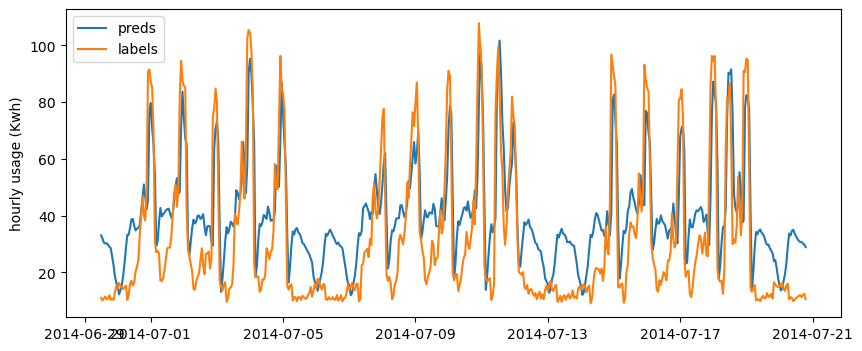

In [194]:
plt.figure(figsize=(10, 4))

start_idx = 128*20
idx_range_to_plot = 4*128
client_to_plot = 159

plt.plot(datetime_for_tests[start_idx: start_idx + idx_range_to_plot], preds_dict_unscaled[client_to_plot][start_idx: start_idx + idx_range_to_plot], label='preds')
plt.plot(datetime_for_tests[start_idx: start_idx + idx_range_to_plot], labels_dict_unscaled[client_to_plot][start_idx: start_idx + idx_range_to_plot], label='labels')
plt.ylabel('hourly usage (Kwh)')
plt.legend()
plt.show()